### Solving Biharmonic PDE with Neural Networks within a circle

Key features:
- Swish activation
- Predefined generator
- Decreasing NN
- Fast training
- Enhanced plotting

In [1]:
# Libraries
from neurodiffeq.operators import laplacian
from neurodiffeq.conditions import BaseCondition
from neurodiffeq.callbacks import ActionCallback
from neurodiffeq.networks import FCNN, Swish
from neurodiffeq.generators import PredefinedGenerator
from neurodiffeq.solvers import Solver2D

import torch
from torch.optim import AdamW
from torch.nn import MSELoss

import numpy as np

import matplotlib.pyplot as plt

In [2]:
# Boundary conditions class
class ClampedCircleCondition(BaseCondition):
    def __init__(self):
        super().__init__()
        
    def parameterize(self, output_tensor, *input_tensors): # Output transformation to satisfy boundary conditions
        return output_tensor * (1 - input_tensors[0] ** 2 - input_tensors[1] ** 2) ** 2
        
    def enforce(self, net, *coordinates): # Apply the parameterize()
        return self.parameterize(net(torch.cat(coordinates, dim = 1)), *coordinates)

# Custom monitor callback
class PrintLossesCallback(ActionCallback):
    def __init__(self, print_every = 50):
        super().__init__()

        self.print_every = print_every
    
    def __call__(self, solver): # Action done
        current_epoch = len(solver.metrics_history["train_loss"])
        
        if current_epoch % self.print_every == 0: # Check if it's time to print (every print_every epochs)
            train_loss = solver.metrics_history["train_loss"][-1]
            valid_loss = solver.metrics_history["valid_loss"][-1]
            
            print(f"Epoch {current_epoch:4d} | Train Loss: {train_loss:.6e} | Valid Loss: {valid_loss:.6e}")

# Neural network
nets = FCNN(n_input_units = 2,
            n_output_units = 1,
            hidden_units = (64, 32, 16, 8, 4, 2),
            actv = Swish)

# Dataset generation
def create_polar_grid_spiral(n_points):
    indices = torch.arange(0, n_points)
    golden_angle = torch.pi * (3.0 - torch.sqrt(torch.tensor(5.0)))
    
    theta = golden_angle * indices
    r = torch.sqrt(indices / (n_points - 1))
    
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    return (x, y)

train_generator = PredefinedGenerator(*create_polar_grid_spiral(1_000))
valid_generator = PredefinedGenerator(*create_polar_grid_spiral(500))

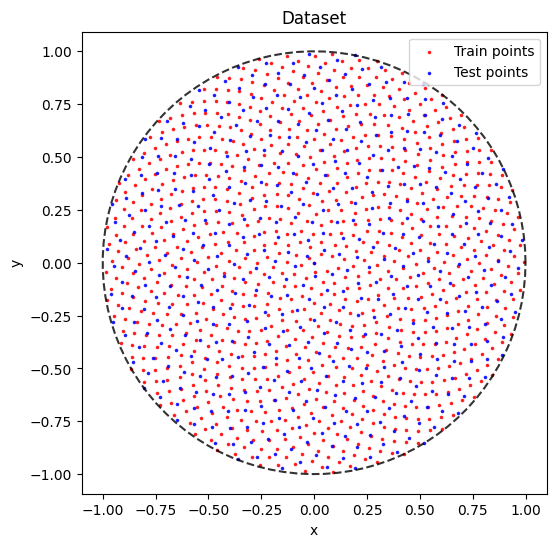

In [3]:
# Plotting the grid
x_train, y_train = train_generator.get_examples()
x_train = x_train.detach().numpy()
y_train = y_train.detach().numpy()

x_test, y_test = valid_generator.get_examples()
x_test = x_test.detach().numpy()
y_test = y_test.detach().numpy()

plt.figure(figsize = (6, 6))
plt.scatter(x_train, y_train, s = 2.5, alpha = 0.8, color = 'r', label = 'Train points')
plt.scatter(x_test, y_test, s = 2.5, alpha = 0.8, color = 'b', label = 'Test points')

theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha = 0.8)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset')
plt.axis('equal')
plt.grid(False)
plt.legend(loc = 'upper right')
plt.show()

In [ ]:
# Solution class
sol = Solver2D(pde_system = lambda u, x, y: [laplacian(laplacian(u, x, y), x, y) + 5], # Biharmonic PDE with constant load: L(L(u)) = -5
               conditions = [ClampedCircleCondition()],
               xy_min = - 1,
               xy_max = 1,
               nets = [nets],
               train_generator = train_generator,
               valid_generator = valid_generator,
               optimizer = AdamW(nets.parameters(), lr = 1e-02), # AdamW optimizer with lr = 1e-02
               loss_fn = MSELoss(), # Loss function
               n_batches_train = 1,
               n_batches_valid = 1)

In [5]:
# Training the model
sol.fit(max_epochs = 500, callbacks = [PrintLossesCallback()]) # Only monitor callback

Training Progress:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch   50 | Train Loss: 8.208764e-01 | Valid Loss: 1.764904e+00
Epoch  100 | Train Loss: 3.071862e-02 | Valid Loss: 2.418531e-02
Epoch  150 | Train Loss: 4.239283e-03 | Valid Loss: 4.303344e-03
Epoch  200 | Train Loss: 3.634160e-03 | Valid Loss: 3.643410e-03
Epoch  250 | Train Loss: 3.197880e-03 | Valid Loss: 3.201856e-03
Epoch  300 | Train Loss: 2.891545e-03 | Valid Loss: 2.894649e-03
Epoch  350 | Train Loss: 2.676610e-03 | Valid Loss: 2.678252e-03
Epoch  400 | Train Loss: 2.519897e-03 | Valid Loss: 2.519942e-03
Epoch  450 | Train Loss: 2.397637e-03 | Valid Loss: 2.396101e-03
Epoch  500 | Train Loss: 2.293224e-03 | Valid Loss: 2.290234e-03


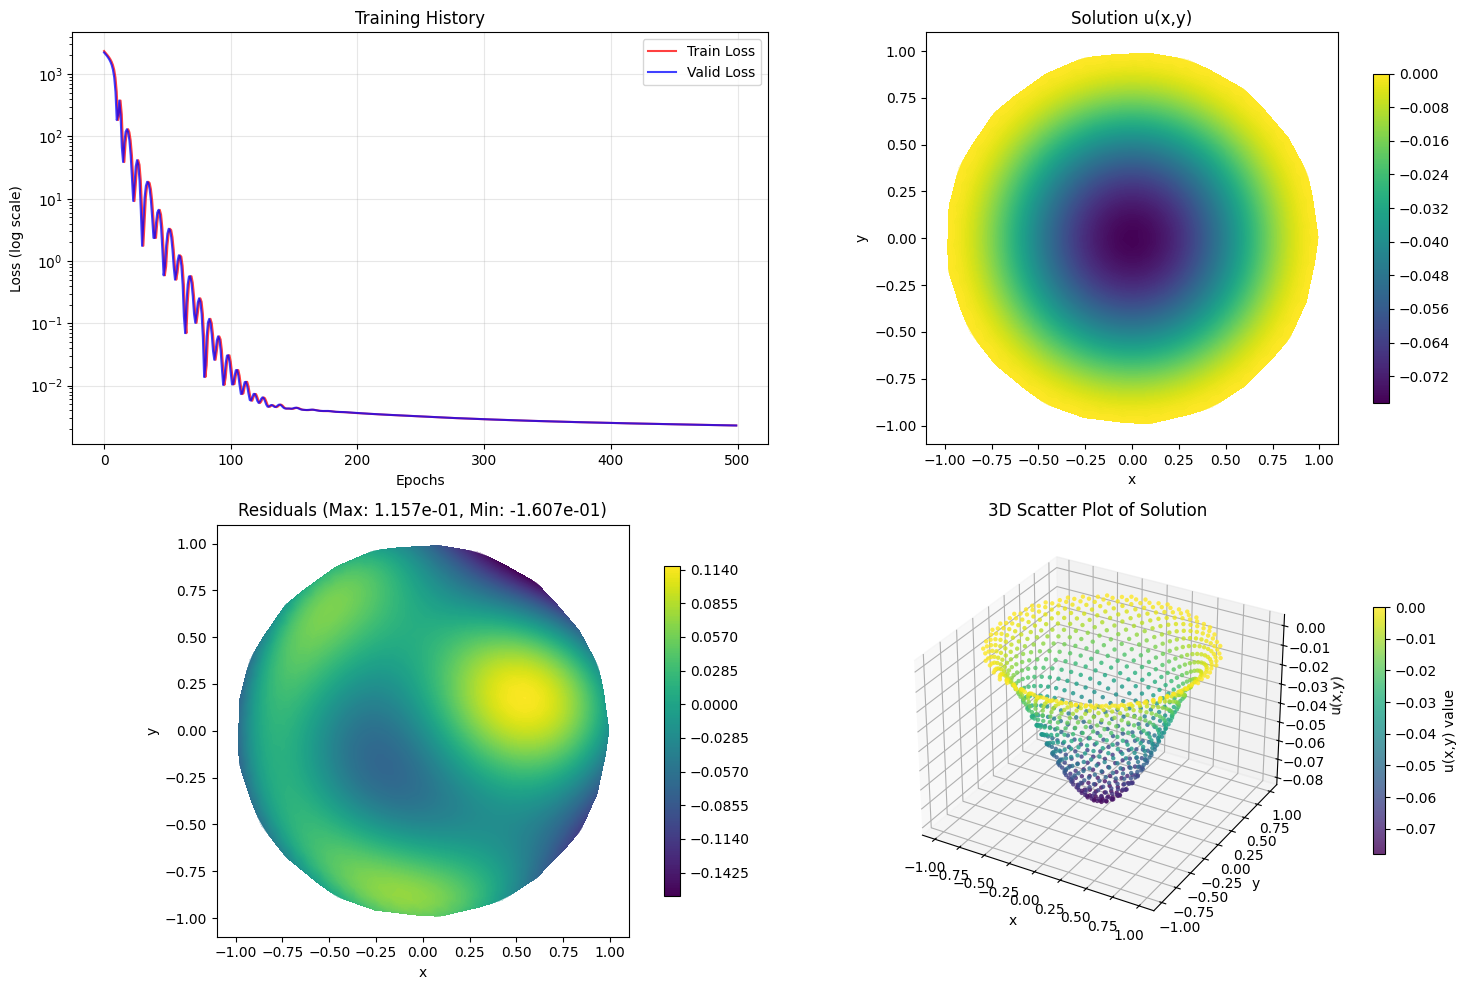

In [6]:
# Get losses
train_loss, valid_loss = sol.metrics_history['train_loss'], sol.metrics_history['valid_loss']

# Get data
solution = sol.get_solution()(x_train, y_train).detach().numpy()
residuals = sol.get_residuals(x_train, y_train).detach().numpy()

# Create figure with 4 subplots
plt.figure(figsize = (15, 10))

# Plot 1: Loss history
ax1 = plt.subplot(2, 2, 1)
ax1.plot(train_loss, 'r-', label = 'Train Loss', linewidth = 1.5, alpha = 0.75)
ax1.plot(valid_loss, 'b-', label = 'Valid Loss', linewidth = 1.5, alpha = 0.75)
ax1.set_yscale('log')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True, alpha = 0.3)

# Plot 2: Solution (tri-contour plot for irregular points)
ax2 = plt.subplot(2, 2, 2)
tricontour = ax2.tricontourf(x_train, y_train, solution, levels = 200, cmap = 'viridis')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Solution u(x,y)')
plt.colorbar(tricontour, ax = ax2, shrink = 0.8)
ax2.set_aspect('equal')

ax2.plot(np.cos(theta), np.sin(theta), 'w-', linewidth = 1, alpha = 0.8) # Plot circle boundary

# Plot 3: Residuals (tri-contour plot for irregular points)
ax3 = plt.subplot(2, 2, 3)
res_tricontour = ax3.tricontourf(x_train, y_train, residuals, levels = 200, cmap = 'viridis')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title(f'Residuals (Max: {residuals.max():.3e}, Min: {residuals.min():.3e})')
plt.colorbar(res_tricontour, ax = ax3, shrink = 0.8)
ax3.set_aspect('equal')

ax3.plot(np.cos(theta), np.sin(theta), 'w-', linewidth = 1, alpha = 0.8) # Plot circle boundary

# Plot 4: 3D scatter plot
ax4 = plt.subplot(2, 2, 4, projection = '3d')
scatter = ax4.scatter(x_train, y_train, solution, c = solution, cmap = 'viridis', s = 10, alpha = 0.8, linewidth = 0)
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('u(x,y)')
ax4.set_title('3D Scatter Plot of Solution')

cbar = plt.colorbar(scatter, ax = ax4, shrink = 0.6, pad = 0.1)
cbar.set_label('u(x,y) value')

plt.tight_layout()
plt.show()

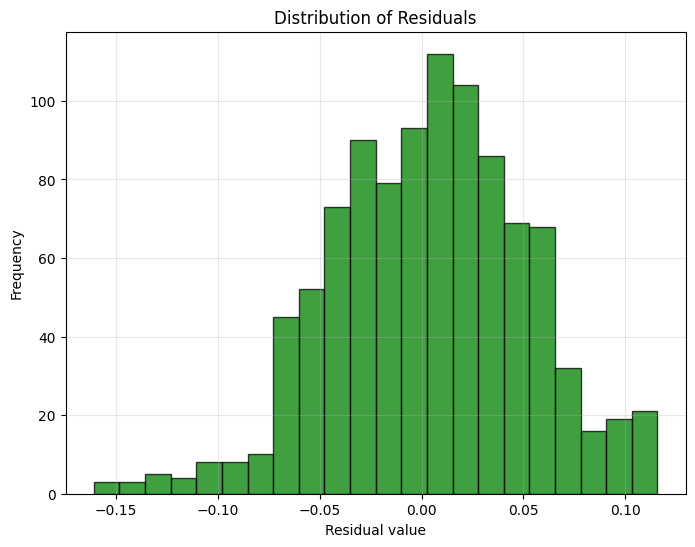

In [7]:
plt.figure(figsize = (8, 6))

# Histogram of residuals
plt.hist(residuals, bins = 'auto', edgecolor = 'black', color = 'green', alpha = 0.75)
plt.xlabel('Residual value')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha = 0.3)
plt.show()